In [77]:
#import packages
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [25]:
#protevtive put
investing = 115
s0 = 110
e = 105
t = 1
option_premium = 5

s1 = np.arange(125,89,-5)
c1 = []
for i in range(len(s1)):
    if s1[i] - e >= 0:
        c1.append(0)
    else:
        c1.append(e-s1[i])

total_value = s1+c1
earn = total_value-115

result = pd.DataFrame({
    "s1": s1,
    "c1": c1,
    "total_value": total_value,
    "earn":earn
})

result

,s1,c1,total_value,earn
0,125,0,125,10
1,120,0,120,5
2,115,0,115,0
3,110,0,110,-5
4,105,0,105,-10
5,100,5,105,-10
6,95,10,105,-10
7,90,15,105,-10


In [ ]:
#alternative strategy, using call option & risk free asset
investing = 115
s0 = 110
e = 105
t = 1
option_premium = 15
rf = 0.05
rf_invest = 100


s1 = np.arange(125,89,-5)
c1 = []
rf_value = []
for i in range(len(s1)):
    if s1[i] - e <= 0:
        c1.append(0)
        rf_value.append(int(rf_invest*(1+rf)))
    else:
        c1.append(s1[i]-e)
        rf_value.append(int(rf_invest*(1+rf)))

total_value = np.array(c1) + np.array(rf_value)

earn = total_value-115

result = pd.DataFrame({
    "s1": s1,
    "c1": c1,
    "rf_value" : rf_value,
    "total_value": total_value,
    "earn":earn
})

result
#At result, it is same. Put Call Parity(PCP)
# 1 Stock + Put Option = C0 + Call option
# S + P = PV(E) + C
# S = PV(E) + C - P


,s1,c1,rf_value,total_value,earn
0,125,20,105,125,10
1,120,15,105,120,5
2,115,10,105,115,0
3,110,5,105,110,-5
4,105,0,105,105,-10
5,100,0,105,105,-10
6,95,0,105,105,-10
7,90,0,105,105,-10


In [3]:
# example 25.1
s0 = 60
t = 6
e = 70
op = 2
rf = 0.004

#PCP : S = PV(E) + C - P
p = 70/(1+rf)**t + 2 - 60

p


10.343271359988208

In [6]:
# Continuous Compounding
def con_ear(r):
    ear = np.exp(r)-1
    return ear

#example 25.3
500*(1+con_ear(-0.09*0.5))


np.float64(477.99874091655)

In [56]:
#Black Shcholes model

# c = s * N(d1) - e * np.exp(-r*t) * N(d2)
def c(s,e,rf,d1,d2):
    c = (s * d1) - (e * rf * d2)
    return c


s = 100
e = 90
rf = np.exp(-0.04 * 3/4)
d1 = 0.6
d2 = 0.3

# Calculating d1 and d2 Using the Cumulative Normal Distribution
n_d1 = norm.cdf(d1)
n_d2 = norm.cdf(d2)

c(s,e,rf,n_d1,n_d2)

np.float64(18.60624404372384)

In [57]:
# Calculating d1 and d2 Using the Black-Scholes Model

def d(s, e, r, sig, t):
    d1 = (np.log(s/e) + (r + (sig**2)/2)*t) / (sig * np.sqrt(t)) 
    d2 = d1 - (sig * np.sqrt(t))

    return d1, d2

d1 = d(70, 80, 0.04, 0.6, 0.25)[0]
d2 = d(70, 80, 0.04, 0.6, 0.25)[1]

c(70,80,np.exp(-0.04*0.25),norm.cdf(d1),norm.cdf(d2))



np.float64(5.030111917409812)

In [58]:
# Evaluation of Put option
s = 40
e = 40
t = 1/3
r = 0.04
sig = 0.8

d1 = d(s,e,r,sig,t)[0]
d2 = d(s,e,r,sig,t)[1]

call = c(s,e,np.exp(-r*t),norm.cdf(d1),norm.cdf(d2))

#put call perity for put option
def put_perity(e,r,c,s):
    p = e*r+c-s
    return p

put_perity(e,np.exp(-r*t),call,s)

np.float64(6.9952397710211045)

In [60]:
#example
s = 70
e = 90
r = 0.08
sig = 0.2
t = 1

d1 = d(s,e,r,sig,t)[0]
d2 = d(s,e,r,sig,t)[1]

call = c(s,e,np.exp(-r*t),norm.cdf(d1),norm.cdf(d2))

put_perity(e,np.exp(-r*t),call,s)

np.float64(14.733053209544025)

In [63]:
#900p

s = 120
e = 100
r = 0.08
sig = 0.80
t = 0.5

d1 = d(s,e,r,sig,t)[0]
d2 = d(s,e,r,sig,t)[1]

call = c(s,e,np.exp(-r*t),norm.cdf(d1),norm.cdf(d2))

put_perity(e,np.exp(-r*t),call,s)

np.float64(13.87724139113621)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\10527824.py:4: RuntimeWarning: invalid value encountered in divide
  d1 = (np.log(s/e) + (r + (sig**2)/2)*t) / (sig * np.sqrt(t))


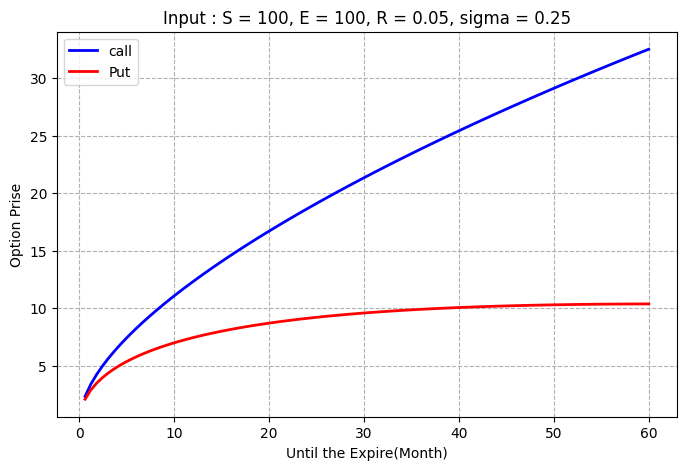

In [85]:
#picture 25.2

s=100
e=100
r=0.05
sig=0.25
t = np.linspace(0,60, 101)

d1 = d(s,e,r,sig,t/12)[0]
d2 = d(s,e,r,sig,t/12)[1]

call = c(s,e,np.exp(-r*t/12),norm.cdf(d1),norm.cdf(d2))

put = put_perity(e,np.exp(-r*t/12),call,s)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(t, call, color = 'blue', linewidth = 2, label = "call")
ax.plot(t, put, color = "red", linewidth = 2, label = "Put")
plt.xlabel("Until the Expire(Month)")
plt.ylabel("Option Prise")
plt.legend()
plt.grid(linestyle = "--")
plt.title(f"Input : S = {s}, E = {e}, R = {r}, sigma = {sig}")
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\10527824.py:4: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(s/e) + (r + (sig**2)/2)*t) / (sig * np.sqrt(t))


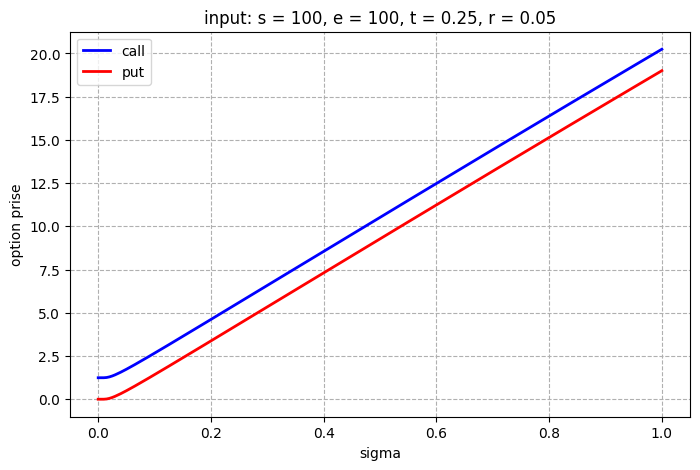

In [92]:
#picture 25.3
s = 100
e = 100
t = 1/4
r = 0.05
sig = np.linspace(0,1,201)

d1 = d(s,e,r,sig,t)[0]
d2 = d(s,e,r,sig,t)[1]

call = c(s,e,np.exp(-r*t),norm.cdf(d1),norm.cdf(d2))
put = put_perity(e,np.exp(-r*t),call,s)

fig, ax = plt.subplots(figsize= (8,5))
ax.plot(sig, call, color="blue", linewidth = 2, label = "call")
ax.plot(sig, put, color="red", linewidth = 2, label = "put")
plt.title(f"input: s = {s}, e = {e}, t = {t}, r = {r}")
plt.legend()
plt.grid(linestyle = "--")
plt.xlabel("sigma")
plt.ylabel("option prise")
plt.show()

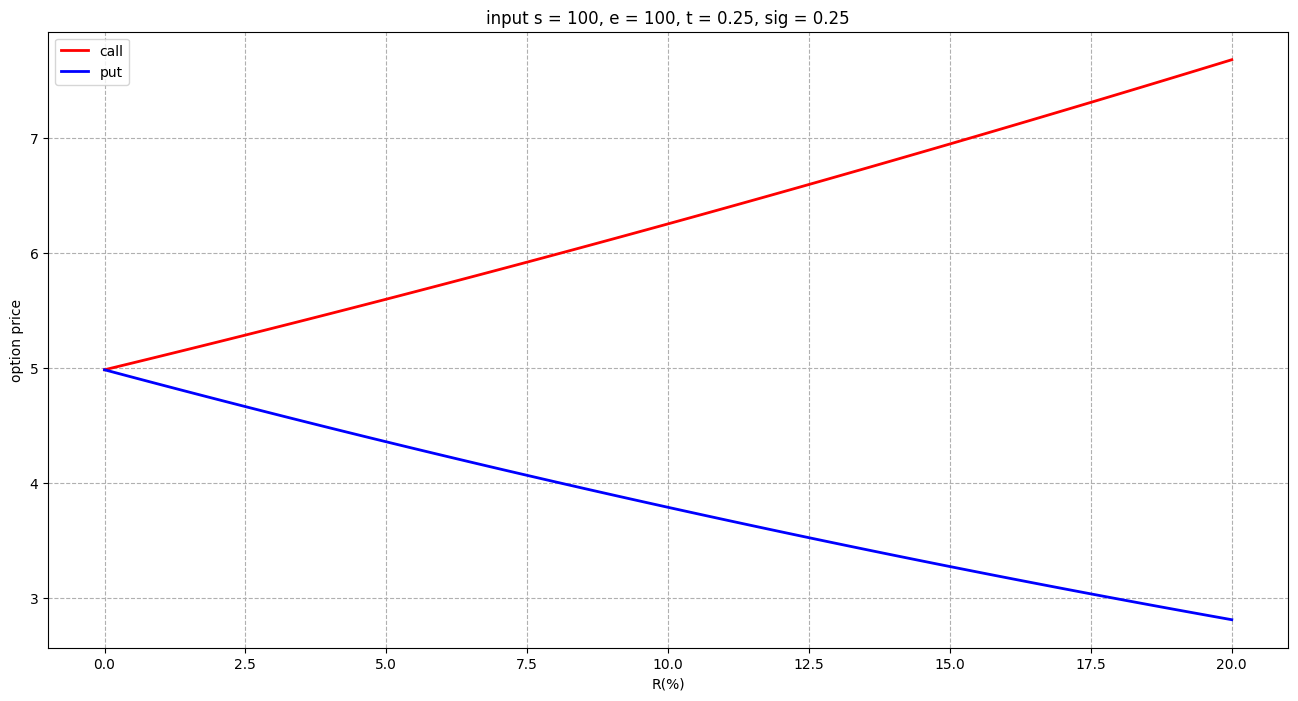

In [106]:
#picture 25.4
s = 100
e = 100
t = 0.25
sig = 0.25
r = np.linspace(0,20,101)

d1 = d(s,e,r/100,sig,t)[0]
d2 = d(s,e,r/100,sig,t)[1]

call = c(s,e,np.exp(-r/100*t),norm.cdf(d1),norm.cdf(d2))
put = put_perity(e,np.exp(-r/100*t),call,s)

fig, ax = plt.subplots(figsize=(16,8))
ax.plot(r, call, color="red", linewidth = 2, label = "call")
ax.plot(r, put, color="blue", linewidth=2, label = "put")
plt.title(f"input s = {s}, e = {e}, t = {t}, sig = {sig}")
plt.xlabel("R(%)")
plt.ylabel("option price")
plt.legend()
plt.grid(linestyle = "--")
plt.show()
